# AI Bubble Analysis
## 1. Price vs Reality Check
**Objective**: AI stock prices have surged — but can revenue keep up?

**Stocks Analyzed**: AMD, AMZN, GOOGL, META, MSFT, NVDA, ORCL, PLTR



In [42]:
## Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

### Helper Functions

### Date Parsing
Revenue files contain multiple date formats:
- ISO format: `2022-03-31` (AMZN)
- Text format: `March 31, 2022` or `August 31,2022` (ORCL)

In [43]:
def parse_date(date_str):
    """Parse various date formats"""
    clean = str(date_str).replace('d ', '').replace('  ', ' ').strip()

    # Try ISO format first (2022-03-31)
    try:
        return pd.to_datetime(clean, format='%Y-%m-%d')
    except:
        pass

    # Try text format with proper spacing
    if ',' in clean and not ', ' in clean:
        clean = clean.replace(',', ', ')

    try:
        return pd.to_datetime(clean, format='%B %d, %Y')
    except:
        pass

    # Fallback to pandas auto-parse
    return pd.to_datetime(clean)

In [44]:
## Load Stock Price Data
stock_price = pd.read_csv('stock_price.csv', parse_dates=['Date'], index_col='Date')
print(f"Shape: {stock_price.shape}")
print(f"Date Range: {stock_price.index.min()} to {stock_price.index.max()}")
stock_price.head()

Shape: (938, 8)
Date Range: 2022-01-03 00:00:00 to 2025-09-29 00:00:00


,AMD,AMZN,GOOGL,META,MSFT,NVDA,ORCL,PLTR
Date,,,,,,,,
2022-01-03,150.240005,170.404495,143.904190,336.191559,323.898407,30.062769,83.032196,18.530001
2022-01-04,144.419998,167.522003,143.316650,334.195526,318.344452,29.233374,83.920151,18.170000
2022-01-05,136.149994,164.356995,136.741791,321.921265,306.123871,27.550631,81.671921,16.959999
2022-01-06,136.229996,163.253998,136.714523,330.153778,303.704956,28.123524,81.861549,16.740000
2022-01-07,132.000000,162.554001,135.989487,329.488434,303.859741,27.194321,82.970894,16.559999


##  Load Revenue Data

### Fiscal Year Correction
Some companies have a Fiscal Year that differs from the Calendar Year:
- **NVDA**: Q4 is reported in Jan of the following year, use the previous year
- **MSFT**: Q3/Q4 are reported in Mar-Jun of the following year, use the previous year
- **ORCL**: Q3/Q4 are reported in Feb-May of the following year, use the previous year

In [45]:
def get_fiscal_year(date, quarter, stock):

    year = date.year
    month = date.month

    if stock == 'NVDA':
        # NVDA: Q4 is announced in Jan/Feb → belongs to previous fiscal year
        if quarter == 'Q4' and month <= 2:
            return year - 1
        else:
            return year

    elif stock == 'MSFT':
        # MSFT Fiscal Year ends in June
        # Q3 and Q4 of fiscal year X are reported in calendar year X+1
        if quarter in ['Q3', 'Q4'] and month <= 6:
            return year - 1
        else:
            return year

    elif stock == 'ORCL':
        # ORCL Fiscal Year ends in May
        # Q3 and Q4 of fiscal year X are reported in calendar year X+1
        if quarter in ['Q3', 'Q4'] and month <= 6:
            return year - 1
        else:
            return year

    else:
        # Other stocks: Calendar Year = Fiscal Year
        return year


def process_revenue_data(df, stock):
    """Process revenue dataframe with correct fiscal year"""
    df = df.copy()
    df['Date'] = df['Fiscal Year'].apply(parse_date)

    # Parse revenue (handle both $ and non-$ formats)
    df['Revenue'] = df['Price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

    df['Stock'] = stock

    # Apply fiscal year correction
    df['Fiscal_Year'] = df.apply(lambda row: get_fiscal_year(row['Date'], row['Quarter'], stock), axis=1)

    # Create Stock_Quarter_Year with corrected fiscal year
    df['Stock_Quarter_Year'] = df['Quarter'] + '/' + df['Fiscal_Year'].astype(str)

    # Also keep original year for reference
    df['Calendar_Year'] = df['Date'].dt.year

    return df[['Date', 'Quarter', 'Fiscal_Year', 'Calendar_Year', 'Revenue', 'Stock', 'Stock_Quarter_Year']]

In [46]:
# Load NVIDIA revenue
nvda_rev = pd.read_csv('Revenue - NVDA.csv')
nvda_rev = process_revenue_data(nvda_rev, 'NVDA')
print(f"NVDA: {len(nvda_rev)} quarters")
print("Fiscal Year Correction Example:")
nvda_rev[['Date', 'Quarter', 'Calendar_Year', 'Fiscal_Year', 'Stock_Quarter_Year']].head(8)


NVDA: 15 quarters
Fiscal Year Correction Example:


,Date,Quarter,Calendar_Year,Fiscal_Year,Stock_Quarter_Year
0,2022-05-01,Q1,2022,2022,Q1/2022
1,2022-07-31,Q2,2022,2022,Q2/2022
2,2022-10-30,Q3,2022,2022,Q3/2022
3,2023-01-29,Q4,2023,2022,Q4/2022
4,2023-04-30,Q1,2023,2023,Q1/2023
5,2023-07-30,Q2,2023,2023,Q2/2023
6,2023-10-29,Q3,2023,2023,Q3/2023
7,2024-01-28,Q4,2024,2023,Q4/2023


In [47]:
# Load AMD revenue (no fiscal year adjustment needed)
amd_rev = pd.read_csv('Revenue - AMD.csv')
amd_rev = process_revenue_data(amd_rev, 'AMD')
print(f"AMD: {len(amd_rev)} quarters")

AMD: 15 quarters


In [48]:
# Load AMZN revenue (no fiscal year adjustment needed)
amzn_rev = pd.read_csv('Revenue - AMZN.csv')
amzn_rev = process_revenue_data(amzn_rev, 'AMZN')
print(f"AMZN: {len(amzn_rev)} quarters")

AMZN: 15 quarters


In [49]:
# Load GOOGL revenue (no fiscal year adjustment needed)
googl_rev = pd.read_csv('Revenue - GOOGL.csv')
googl_rev = process_revenue_data(googl_rev, 'GOOGL')
print(f"GOOGL: {len(googl_rev)} quarters")

GOOGL: 15 quarters


In [50]:
# Load META revenue (no fiscal year adjustment needed)
meta_rev = pd.read_csv('Revenue - META.csv')
meta_rev = process_revenue_data(meta_rev, 'META')
print(f"META: {len(meta_rev)} quarters")

META: 16 quarters


In [51]:
# Load MSFT revenue (fiscal year adjustment needed)
msft_rev = pd.read_csv('Revenue - MSFT.csv')
msft_rev = process_revenue_data(msft_rev, 'MSFT')
print(f"MSFT: {len(msft_rev)} quarters")
print("Fiscal Year Correction Example:")
msft_rev[['Date', 'Quarter', 'Calendar_Year', 'Fiscal_Year', 'Stock_Quarter_Year']].head(8)

MSFT: 14 quarters
Fiscal Year Correction Example:


,Date,Quarter,Calendar_Year,Fiscal_Year,Stock_Quarter_Year
0,2022-09-30,Q1,2022,2022,Q1/2022
1,2022-12-31,Q2,2022,2022,Q2/2022
2,2023-03-31,Q3,2023,2022,Q3/2022
3,2023-06-30,Q4,2023,2022,Q4/2022
4,2023-09-30,Q1,2023,2023,Q1/2023
5,2023-12-31,Q2,2023,2023,Q2/2023
6,2024-03-31,Q3,2024,2023,Q3/2023
7,2024-06-30,Q4,2024,2023,Q4/2023


In [52]:
# Load ORCL revenue (fiscal year adjustment needed, note: 2 spaces in filename)
orcl_rev = pd.read_csv('Revenue -  ORCL.csv')
orcl_rev = process_revenue_data(orcl_rev, 'ORCL')
print(f"ORCL: {len(orcl_rev)} quarters")
print("Fiscal Year Correction Example:")
orcl_rev[['Date', 'Quarter', 'Calendar_Year', 'Fiscal_Year', 'Stock_Quarter_Year']].head(8)

ORCL: 14 quarters
Fiscal Year Correction Example:


,Date,Quarter,Calendar_Year,Fiscal_Year,Stock_Quarter_Year
0,2022-08-31,Q1,2022,2022,Q1/2022
1,2022-11-30,Q2,2022,2022,Q2/2022
2,2023-02-28,Q3,2023,2022,Q3/2022
3,2023-05-31,Q4,2023,2022,Q4/2022
4,2023-08-31,Q1,2023,2023,Q1/2023
5,2023-11-30,Q2,2023,2023,Q2/2023
6,2024-02-29,Q3,2024,2023,Q3/2023
7,2024-05-31,Q4,2024,2023,Q4/2023


In [53]:
# Load PLTR revenue (no fiscal year adjustment needed)
pltr_rev = pd.read_csv('Revenue - PLTR.csv')
pltr_rev = process_revenue_data(pltr_rev, 'PLTR')
print(f"PLTR: {len(pltr_rev)} quarters")

PLTR: 15 quarters


In [54]:
# Combine all revenue data using pd.concat()
# all is 2022 - 2025 q2
all_revenue = pd.concat([nvda_rev, amd_rev, amzn_rev, googl_rev, meta_rev, msft_rev, orcl_rev, pltr_rev], ignore_index=True)

# Apply custom cutoff dates per stock
cutoff_dates = {
    'MSFT': pd.to_datetime('2025-12-31'),
    'ORCL': pd.to_datetime('2025-11-30'),
    'NVDA': pd.to_datetime('2025-07-27'),
    'AMD': pd.to_datetime('2025-06-30'),
    'AMZN': pd.to_datetime('2025-06-30'),
    'GOOGL': pd.to_datetime('2025-06-30'),
    'META': pd.to_datetime('2025-06-30'),
    'PLTR': pd.to_datetime('2025-06-30'),
}

def apply_cutoff(row):
    cutoff = cutoff_dates.get(row['Stock'], pd.to_datetime('2025-06-30'))
    return row['Date'] <= cutoff

all_revenue = all_revenue[all_revenue.apply(apply_cutoff, axis=1)]

print("Quarters per stock after cutoff:")
print(all_revenue.groupby('Stock').size())


Quarters per stock after cutoff:
Stock
AMD      14
AMZN     14
GOOGL    14
META     14
MSFT     14
NVDA     14
ORCL     14
PLTR     14
dtype: int64


In [55]:
# Prepare price data in long format using pd.melt()
# Prepare price data per stock
price_long = stock_price.reset_index().melt(
    id_vars=['Date'],
    var_name='Stock',
    value_name='Stock_Price'
).sort_values(['Stock', 'Date'])

price_long.head()


,Date,Stock,Stock_Price
0,2022-01-03,AMD,150.240005
1,2022-01-04,AMD,144.419998
2,2022-01-05,AMD,136.149994
3,2022-01-06,AMD,136.229996
4,2022-01-07,AMD,132.000000


## Match Stock Prices to Revenue Dates

Use `pd.merge_asof()` to match stock prices with revenue announcement dates

In [56]:
# Match prices to revenue using merge_asof for each stock
all_revenue_sorted = all_revenue.sort_values('Date')
matched_list = []

for stock in all_revenue['Stock'].unique():
    rev_stock = all_revenue_sorted[all_revenue_sorted['Stock'] == stock].copy()
    price_stock = price_long[price_long['Stock'] == stock].sort_values('Date')

    matched = pd.merge_asof(
        rev_stock,
        price_stock[['Date', 'Stock_Price']],
        on='Date',
        direction='backward'
    )
    matched_list.append(matched)

matched_data = pd.concat(matched_list, ignore_index=True).dropna(subset=['Stock_Price'])
print(f"Matched {len(matched_data)} revenue-price pairs")
print("\nQuarters per stock after matching:")
print(matched_data.groupby('Stock').size())


Matched 112 revenue-price pairs

Quarters per stock after matching:
Stock
AMD      14
AMZN     14
GOOGL    14
META     14
MSFT     14
NVDA     14
ORCL     14
PLTR     14
dtype: int64


## Calculate Growth Metrics

In [57]:
# Sort data by stock and date
matched_data = matched_data.sort_values(['Stock', 'Date'])

# Get first value per stock using transform('first')
matched_data['Base_Price'] = matched_data.groupby('Stock')['Stock_Price'].transform('first')
matched_data['Base_Revenue'] = matched_data.groupby('Stock')['Revenue'].transform('first')

# Calculate cumulative growth percentage
matched_data['Price_Growth'] = ((matched_data['Stock_Price'] - matched_data['Base_Price']) / matched_data['Base_Price']) * 100
matched_data['Revenue_Growth'] = ((matched_data['Revenue'] - matched_data['Base_Revenue']) / matched_data['Base_Revenue']) * 100

# Calculate Growth Gap (Bubble Signal)
matched_data['Growth_Gap'] = matched_data['Price_Growth'] - matched_data['Revenue_Growth']

matched_data[['Stock_Quarter_Year', 'Price_Growth', 'Revenue_Growth', 'Growth_Gap']].tail(10)

display(matched_data)

,Date,Quarter,Fiscal_Year,Calendar_Year,Revenue,Stock,Stock_Quarter_Year,Stock_Price,Base_Price,Base_Revenue,Price_Growth,Revenue_Growth,Growth_Gap
14,2022-03-26,Q1,2022,2022,5887.0,AMD,Q1/2022,119.669998,119.669998,5887.0,0.000000,0.000000,0.000000
15,2022-06-25,Q2,2022,2022,6550.0,AMD,Q2/2022,87.080002,119.669998,5887.0,-27.233222,11.262103,-38.495325
16,2022-09-24,Q3,2022,2022,5565.0,AMD,Q3/2022,67.959999,119.669998,5887.0,-43.210495,-5.469679,-37.740816
17,2022-12-31,Q4,2022,2022,5599.0,AMD,Q4/2022,64.769997,119.669998,5887.0,-45.876161,-4.892135,-40.984026
18,2023-04-01,Q1,2023,2023,5353.0,AMD,Q1/2023,98.010002,119.669998,5887.0,-18.099771,-9.070834,-9.028937
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,2024-06-30,Q2,2024,2024,678134.0,PLTR,Q2/2024,25.330000,13.730000,446357.0,84.486531,51.926373,32.560159
108,2024-09-30,Q3,2024,2024,725516.0,PLTR,Q3/2024,37.200001,13.730000,446357.0,170.939563,62.541643,108.397920
109,2024-12-31,Q4,2024,2024,827519.0,PLTR,Q4/2024,75.629997,13.730000,446357.0,450.837580,85.393978,365.443602
110,2025-03-31,Q1,2025,2025,883855.0,PLTR,Q1/2025,84.400002,13.730000,446357.0,514.712340,98.015266,416.697075


##  Analysis Summary

In [58]:
# Get latest data for each stock
summary = matched_data.groupby('Stock').last()[['Stock_Quarter_Year', 'Date', 'Price_Growth', 'Revenue_Growth', 'Growth_Gap']]
summary = summary.sort_values('Growth_Gap', ascending=False)
summary

display(summary)

,Stock_Quarter_Year,Date,Price_Growth,Revenue_Growth,Growth_Gap
Stock,,,,,
PLTR,Q2/2025,2025-06-30,892.862432,124.864178,767.998253
NVDA,Q2/2025,2025-07-27,837.008603,463.984073,373.024530
ORCL,Q2/2025,2025-11-30,297.105256,40.305810,256.799446
META,Q2/2025,2025-06-30,233.755741,70.259424,163.496317
MSFT,Q2/2025,2025-12-31,126.449667,62.150353,64.299314
AMZN,Q2/2025,2025-06-30,34.597158,44.019443,-9.422285
AMD,Q2/2025,2025-06-28,20.172140,30.541872,-10.369732
GOOGL,Q2/2025,2025-06-30,27.482646,41.782947,-14.300301


## Price vs Revenue Growth

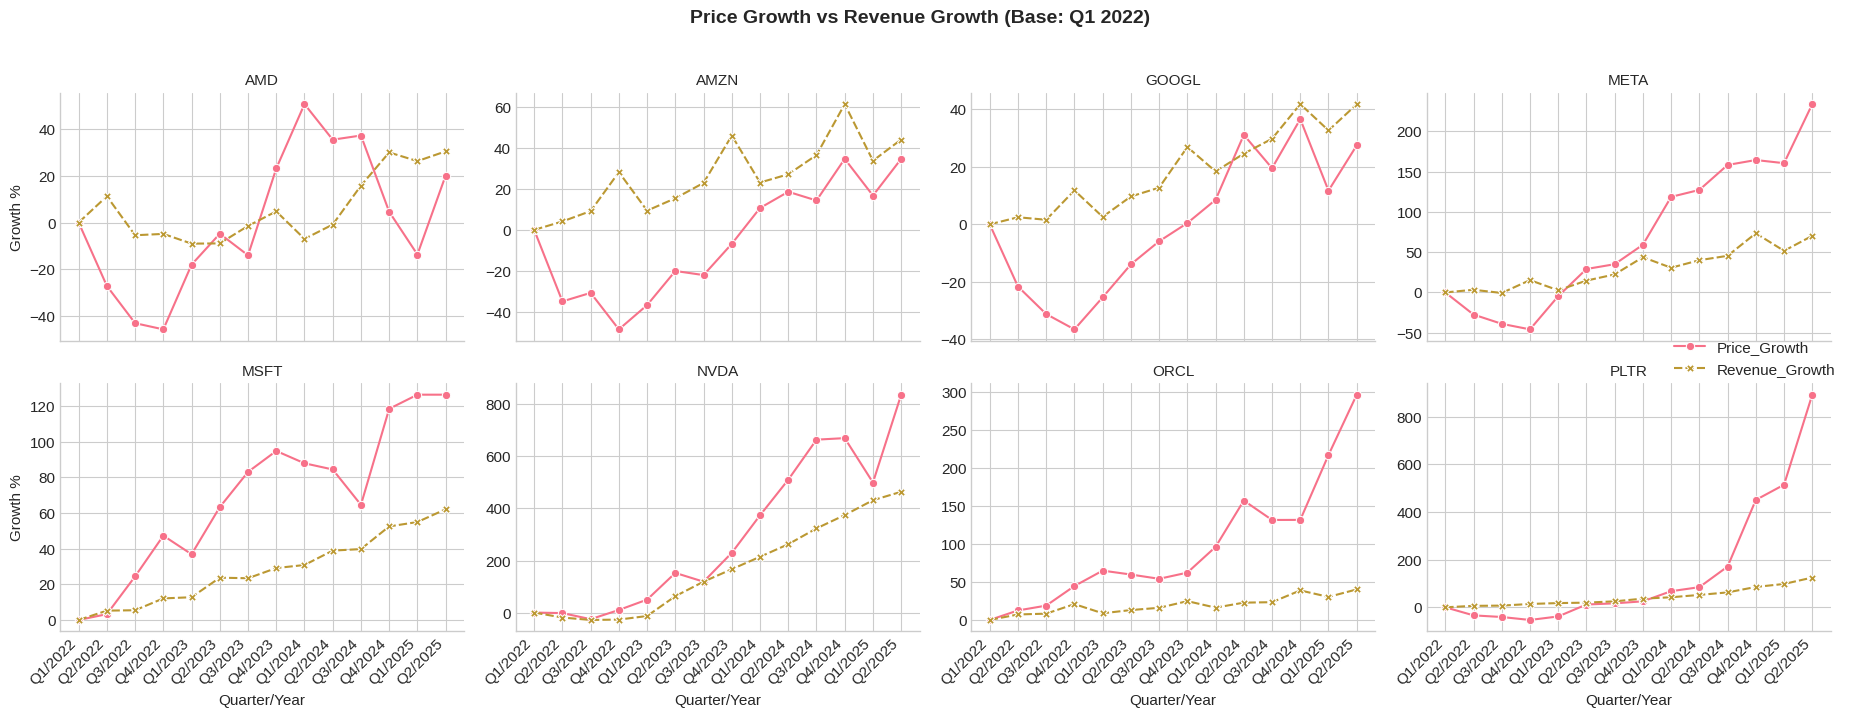

In [59]:
# Reshape data using pd.melt()
plot_data = matched_data.melt(
    id_vars=['Stock', 'Stock_Quarter_Year'],
    value_vars=['Price_Growth', 'Revenue_Growth'],
    var_name='Metric',
    value_name='Growth_Pct'
)

# Create FacetGrid using Stock_Quarter_Year
g = sns.FacetGrid(plot_data, col='Stock', col_wrap=4, height=3.5, aspect=1.2, sharey=False)
g.map_dataframe(sns.lineplot, x='Stock_Quarter_Year', y='Growth_Pct', hue='Metric', markers=True, style='Metric')
g.add_legend()
g.set_titles('{col_name}')
g.set_axis_labels('Quarter/Year', 'Growth %')

# Rotate x labels for readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
        # Show only Q/Year part (remove stock prefix)
        text = label.get_text()
        if ' - ' in text:
            label.set_text(text.split(' - ')[1])

g.figure.suptitle('Price Growth vs Revenue Growth (Base: Q1 2022)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure1.png', dpi=300, bbox_inches='tight')
plt.show()

## AI Bubble Score

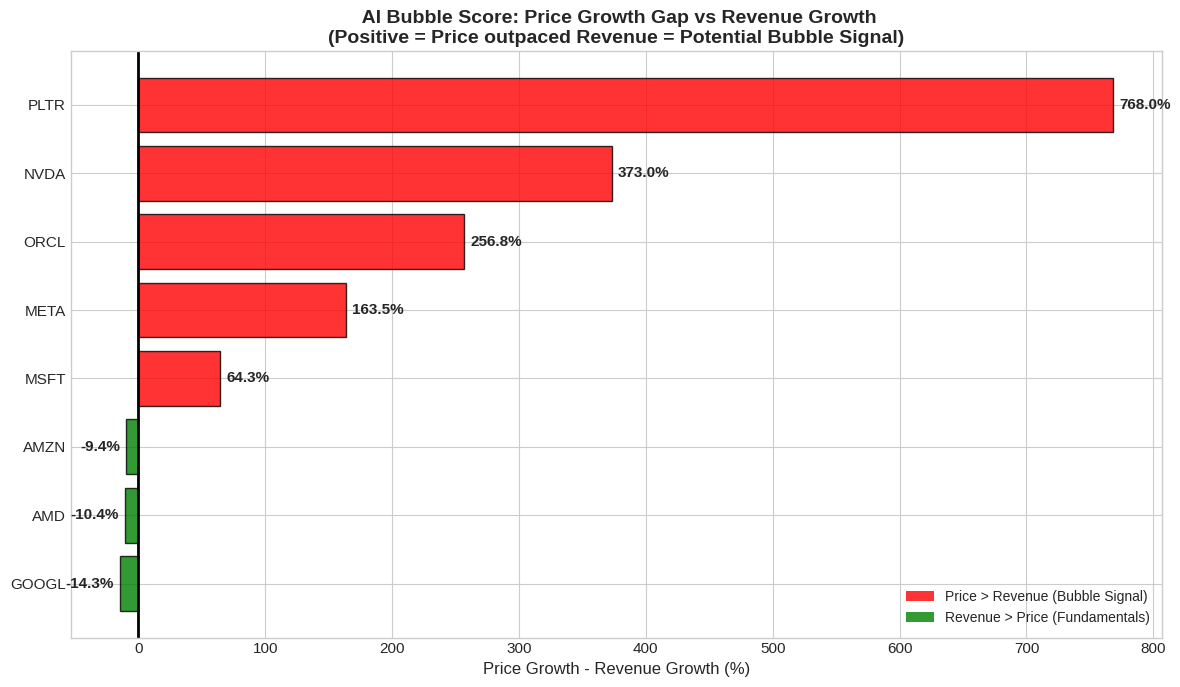

In [60]:
# Get latest data per stock, sorted by Growth Gap
latest = matched_data.loc[matched_data.groupby('Stock')['Date'].idxmax()].sort_values('Growth_Gap')

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Color bars based on positive/negative gap
colors = ['green' if x < 0 else 'red' for x in latest['Growth_Gap']]

# Create horizontal bar chart
bars = ax.barh(latest['Stock'], latest['Growth_Gap'], color=colors, alpha=0.8, edgecolor='black')

# Add value labels on bars (only percentage, no quarter/year)
for bar, val in zip(bars, latest['Growth_Gap']):
    x_pos = val + (5 if val >= 0 else -5)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', ha='left' if val >= 0 else 'right', fontweight='bold', fontsize=11)

ax.axvline(x=0, color='black', linewidth=2)
ax.set_xlabel('Price Growth - Revenue Growth (%)', fontsize=12)
ax.set_title(' AI Bubble Score: Price Growth Gap vs Revenue Growth\n(Positive = Price outpaced Revenue = Potential Bubble Signal)',
             fontsize=14, fontweight='bold')

legend_elements = [Patch(facecolor='red', alpha=0.8, label='Price > Revenue (Bubble Signal)'),
                  Patch(facecolor='green', alpha=0.8, label='Revenue > Price (Fundamentals)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('figure2.png', dpi=300)
plt.show()

## Deep Dive All Stocks with Key Events

In [61]:
def create_stock_deepdive_v2(stock_symbol, stock_data, events, info, save=True):

    data = stock_data[stock_data['Stock'] == stock_symbol].sort_values('Date').reset_index(drop=True)

    if len(data) == 0:
        print(f"No data for {stock_symbol}")
        return

    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Create x-axis positions
    x_pos = np.arange(len(data))
    x_labels = [sqy.split(' - ')[1] if ' - ' in sqy else sqy for sqy in data['Stock_Quarter_Year']]

    # Price line (left axis)
    color1 = 'tab:blue'
    ax1.plot(x_pos, data['Stock_Price'], 'o-', color=color1, linewidth=2.5, markersize=7, label='Stock Price')
    ax1.set_ylabel('Stock Price ($)', color=color1, fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(x_labels, rotation=45, ha='right')

    # Revenue bars  — convert to Billions
    ax2 = ax1.twinx()
    color2 = 'tab:green'
    # Convert revenue to Billion
    if stock_symbol == 'PLTR':
        revenue_display = data['Revenue'] / 1_000_000
    else:
        revenue_display = data['Revenue'] / 1_000
    ax2.bar(x_pos, revenue_display, color=color2, alpha=0.4, width=0.6, label='Revenue ($B)')
    ax2.set_ylabel('Revenue ($ Billion)', color=color2, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color2)

    # Disable secondary grid
    ax2.grid(False)

    # Plot key events - position annotations near bottom, staggered
    colors_events = ['red', 'purple', 'orange', 'brown', 'darkgreen']
    y_min, y_max = ax1.get_ylim()

    for i, (date_str, event_name) in enumerate(events):
        event_date = pd.to_datetime(date_str)
        for j, d in enumerate(data['Date']):
            if d >= event_date:
                color_event = colors_events[i % len(colors_events)]
                ax1.axvline(x=j-0.5, color=color_event, linestyle='--', alpha=0.7, linewidth=1.5)

                # Position: first 2 events near bottom, rest near top
                if i < 2:
                    # Lower area for first 2 events
                    y_offset = 0.25 + (i * 0.08)
                    y_pos = y_min + (y_max - y_min) * y_offset
                else:
                    # Upper area for more 3 events
                    y_offset = 0.75 + ((i - 2) * 0.08)
                    y_pos = y_min + (y_max - y_min) * min(0.95, y_offset)

                ax1.annotate(event_name, xy=(j-0.5, y_pos),
                            fontsize=9, color=color_event, fontweight='bold',
                            rotation=45, ha='left', va='bottom',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor=color_event))
                break

    # Get latest growth gap
    latest_row = data.iloc[-1]
    gap = latest_row['Growth_Gap']
    gap_color = 'red' if gap > 0 else 'green'
    gap_text = f"Gap: {gap:+.1f}%"

    # Title - split into two lines
    title_line1 = f"{info['name']} ({stock_symbol}): {info['desc']}"
    title_line2 = f"Price Growth: {latest_row['Price_Growth']:.1f}% | Revenue Growth: {latest_row['Revenue_Growth']:.1f}%"
    ax1.set_title(f"{title_line1}\n{title_line2}", fontsize=14, fontweight='bold')

    # Gap text at top left
    ax1.text(0.02, 0.98, gap_text, transform=ax1.transAxes, fontsize=14, fontweight='bold',
             color='white', ha='left', va='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor=gap_color, alpha=0.9))

    # Legend below Gap box
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0.0, 0.88), fontsize=10)

    plt.tight_layout()

    if save:
        filename = f'figure3_{stock_symbol.lower()}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")

    plt.show()


In [62]:
# Define key events for each stock
stock_events = {
    'NVDA': [
        ('2022-11-30', 'ChatGPT Launch'),
        ('2023-05-24', 'Record Guidance $11B'),
        ('2024-03-18', 'GTC 2024: Blackwell'),
        ('2024-06-10', '10:1 Stock Split'),
    ],
    'AMD': [
        ('2022-02-14', 'Xilinx Acquisition'),
        ('2023-06-13', 'MI300 AI Chip Reveal'),
        ('2024-04-04', 'Acquired Silo AI'),
        ('2024-10-10', 'MI325X Launch'),
    ],
    'AMZN': [
        ('2022-11-30', 'ChatGPT Launch'),
        ('2023-04-13', 'Bedrock AI Launch'),
        ('2023-09-25', 'Anthropic $4B Deal'),
        ('2024-11-22', 'Nova AI Models'),
    ],
    'GOOGL': [
        ('2022-11-30', 'ChatGPT Launch'),
        ('2023-02-06', 'Bard AI Launch'),
        ('2023-12-06', 'Gemini AI Release'),
        ('2024-05-14', 'I/O: Gemini 1.5'),
    ],
    'META': [
        ('2022-10-28', 'Metaverse Losses'),
        ('2023-02-01', 'Year of Efficiency'),
        ('2023-07-26', 'Llama 2 Open Source'),
        ('2024-04-18', 'Llama 3 Release'),
    ],
    'MSFT': [
        ('2023-01-23', 'OpenAI $10B Deal'),
        ('2023-02-07', 'Bing AI Launch'),
        ('2023-03-16', 'Copilot 365'),
        ('2024-01-29', 'Copilot Pro Launch'),
    ],
    'ORCL': [
        ('2023-06-13', 'AI/Cloud Strategy'),
        ('2024-03-06', 'NVIDIA Partnership'),
        ('2024-09-09', 'AWS Partnership'),
        ('2024-12-09', 'Oracle Cloud Surge'),
    ],
    'PLTR': [
        ('2023-04-26', 'AIP Platform Launch'),
        ('2023-08-07', 'First Profitable Q'),
        ('2024-02-05', 'AIP Bootcamps'),
        ('2024-09-23', 'S&P 500 Entry'),
    ],
}

stock_info = {
    'NVDA': {'name': 'NVIDIA', 'emoji': '', 'desc': 'AI Chip Leader'},
    'AMD': {'name': 'AMD', 'emoji': '', 'desc': 'AI Chip Challenger'},
    'AMZN': {'name': 'Amazon', 'emoji': '', 'desc': 'AWS Cloud AI'},
    'GOOGL': {'name': 'Alphabet (Google)', 'emoji': '', 'desc': 'AI Search & Cloud'},
    'META': {'name': 'Meta (Facebook)', 'emoji': '', 'desc': 'Social AI & LLaMA'},
    'MSFT': {'name': 'Microsoft', 'emoji': '', 'desc': 'OpenAI & Copilot'},
    'ORCL': {'name': 'Oracle', 'emoji': '', 'desc': 'Cloud & Enterprise AI'},
    'PLTR': {'name': 'Palantir', 'emoji': '', 'desc': 'AI Analytics Platform'},
}

Saved: figure3_pltr.png


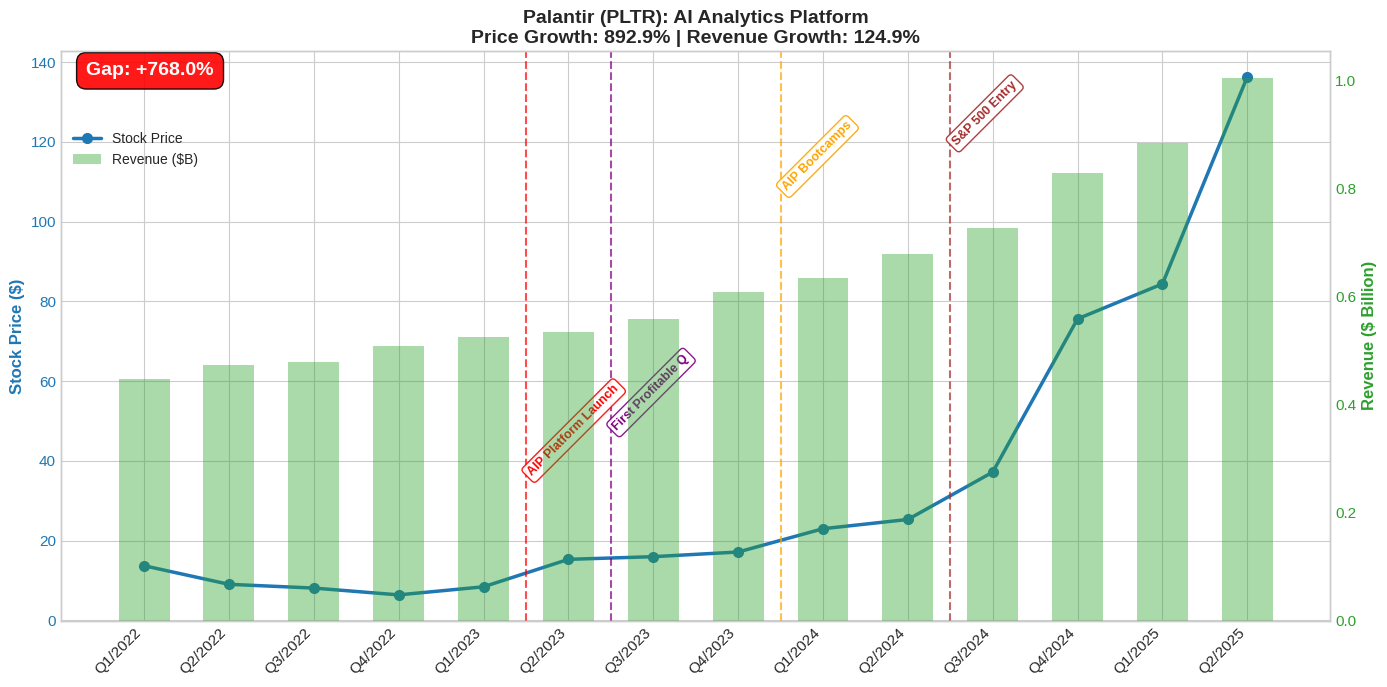

In [63]:
create_stock_deepdive_v2('PLTR', matched_data, stock_events['PLTR'], stock_info['PLTR'])

Saved: figure3_nvda.png


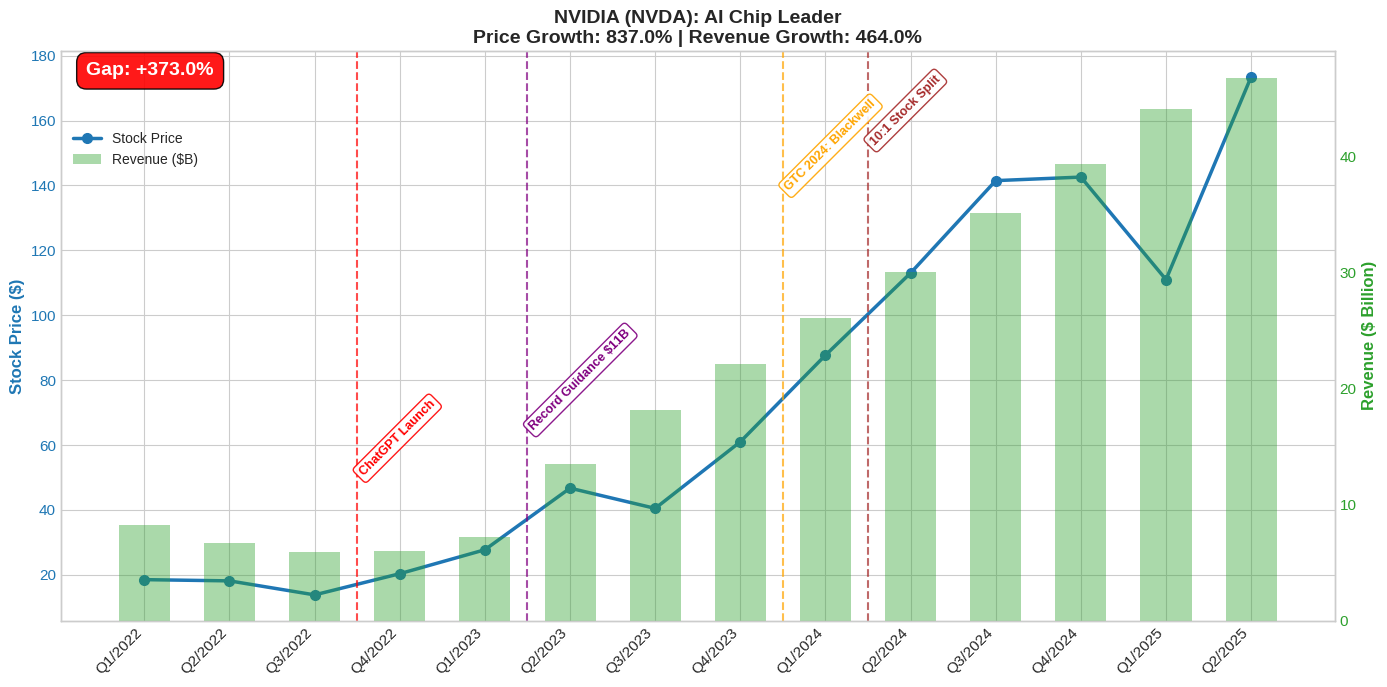

In [64]:
create_stock_deepdive_v2('NVDA', matched_data, stock_events['NVDA'], stock_info['NVDA'])

Saved: figure3_orcl.png


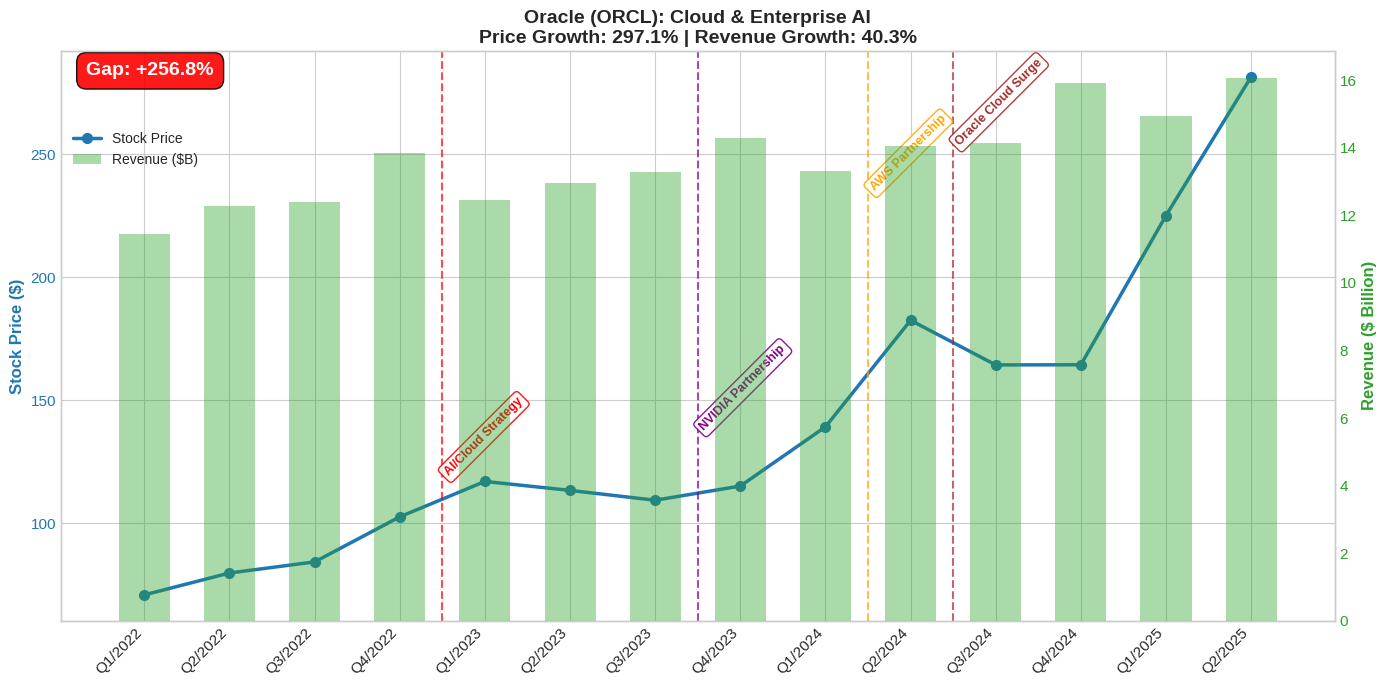

In [65]:
create_stock_deepdive_v2('ORCL', matched_data, stock_events['ORCL'], stock_info['ORCL'])

Saved: figure3_meta.png


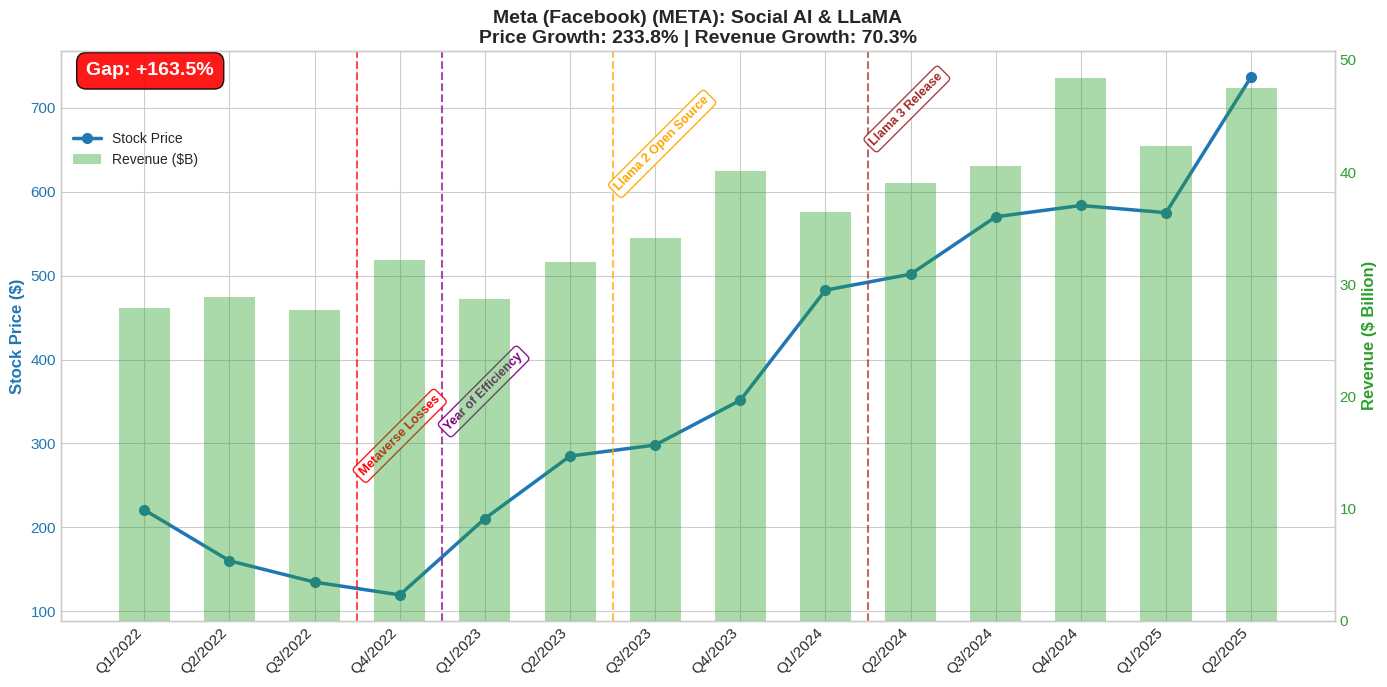

In [66]:
create_stock_deepdive_v2('META', matched_data, stock_events['META'], stock_info['META'])

Saved: figure3_msft.png


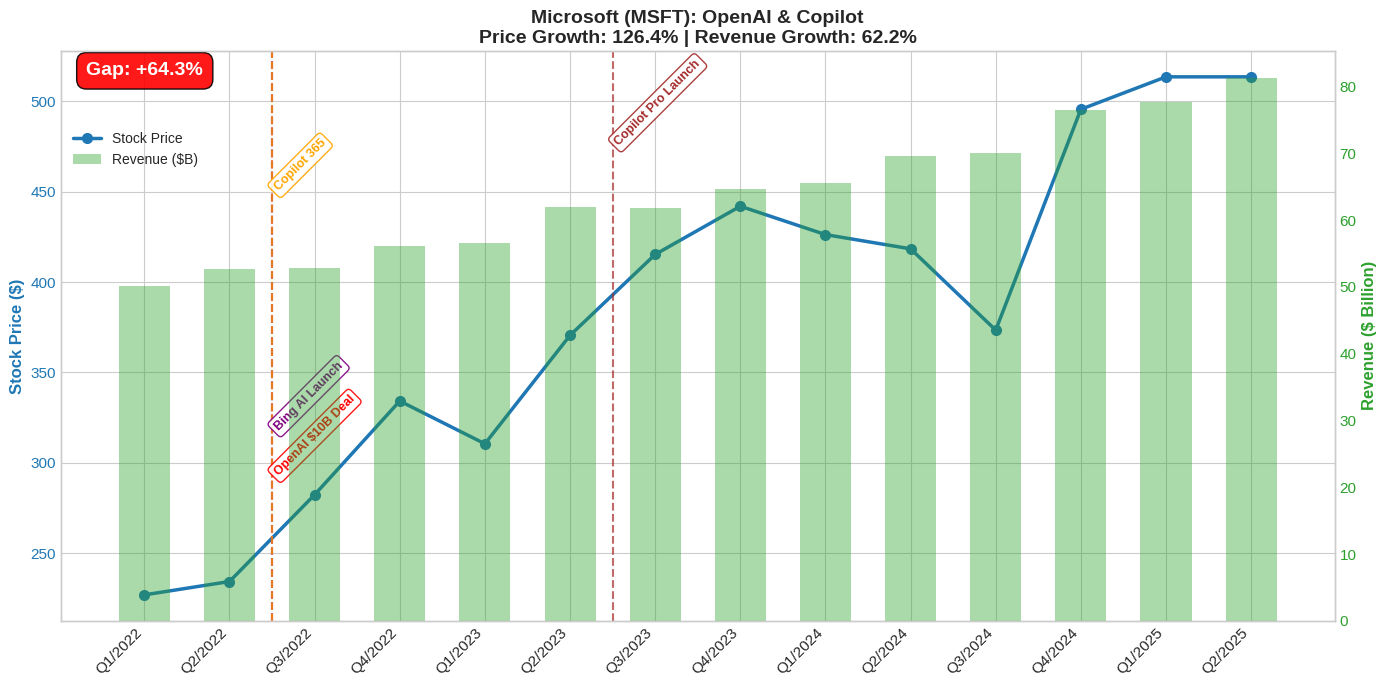

In [67]:
create_stock_deepdive_v2('MSFT', matched_data, stock_events['MSFT'], stock_info['MSFT'])

Saved: figure3_amzn.png


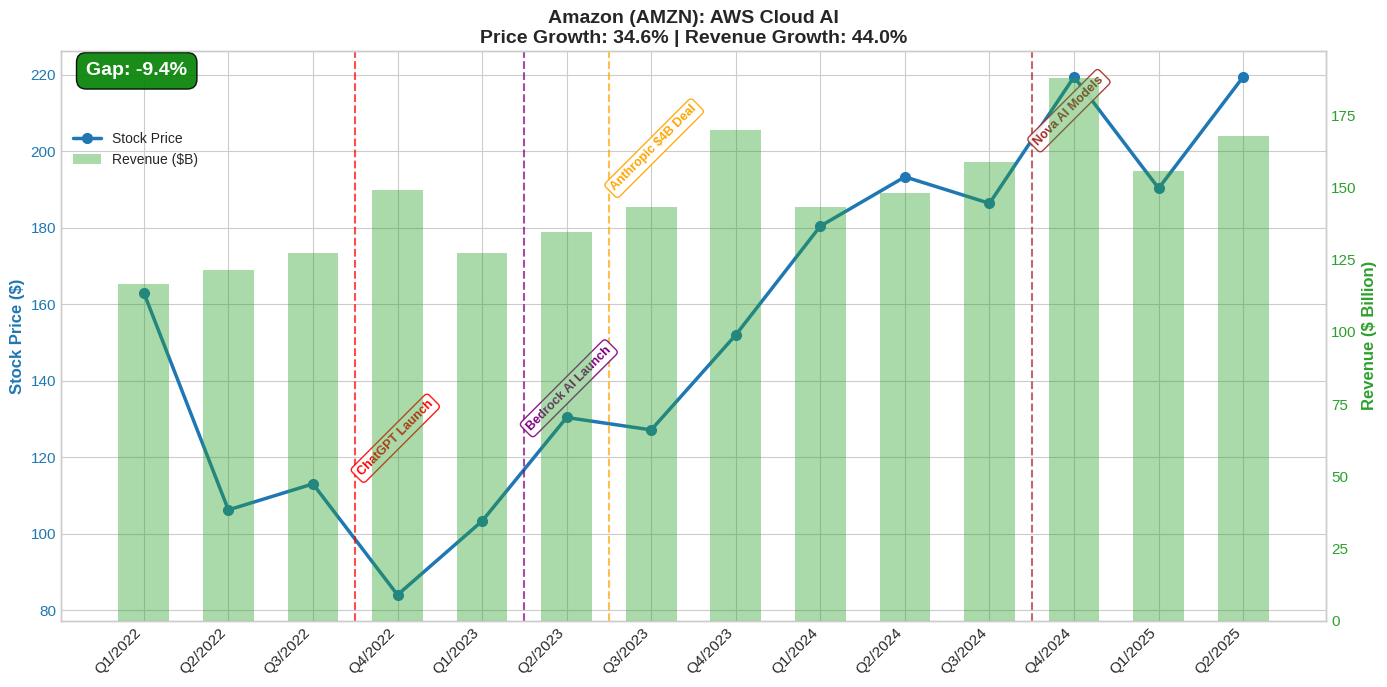

In [68]:
create_stock_deepdive_v2('AMZN', matched_data, stock_events['AMZN'], stock_info['AMZN'])

Saved: figure3_amd.png


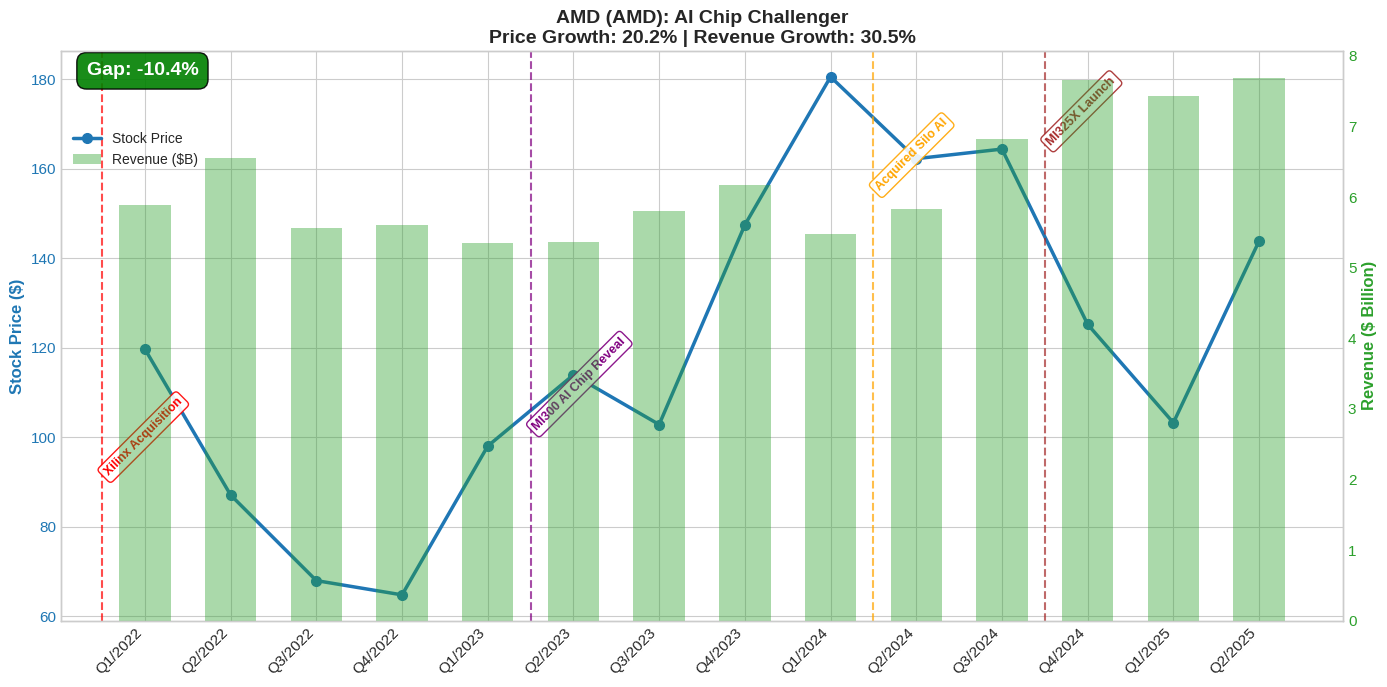

In [69]:
create_stock_deepdive_v2('AMD', matched_data, stock_events['AMD'], stock_info['AMD'])

Saved: figure3_googl.png


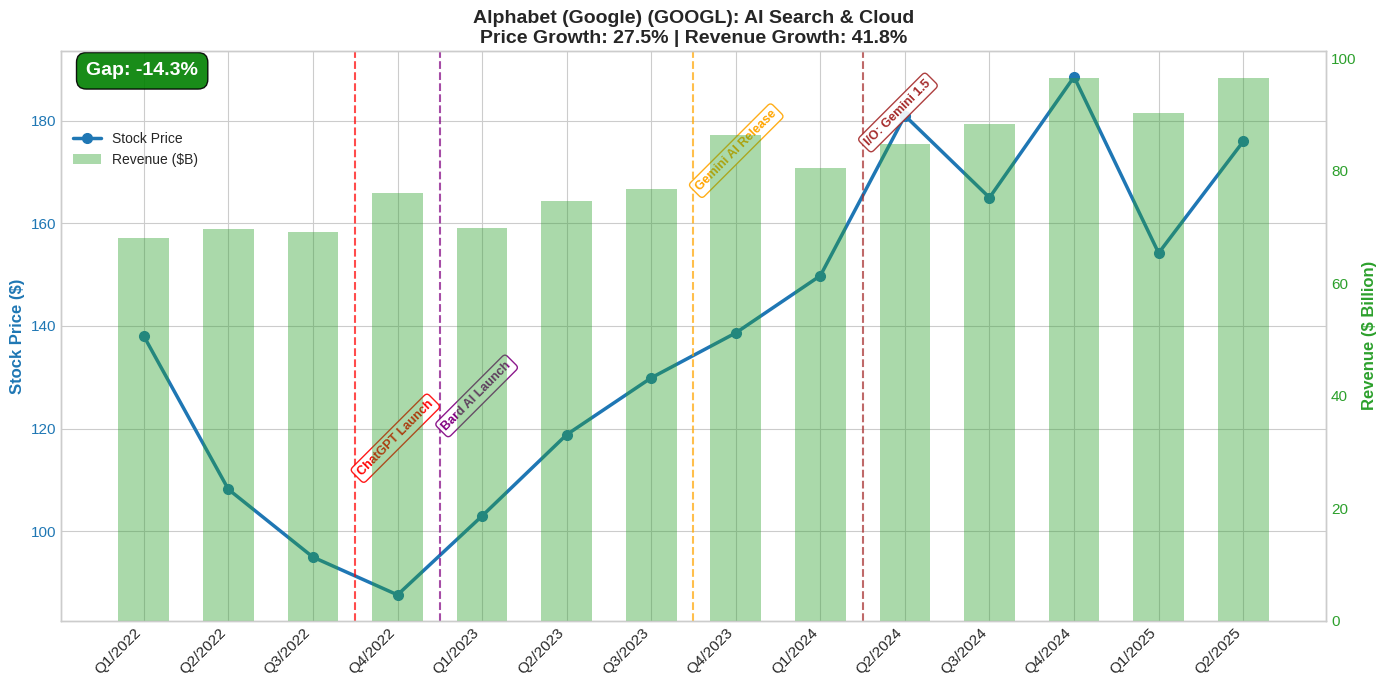

In [70]:
create_stock_deepdive_v2('GOOGL', matched_data, stock_events['GOOGL'], stock_info['GOOGL'])

---

## Section 2: YoY Growth Analysis

This section analyzes Year-over-Year growth to evaluate:
1. **%YoY Growth** - Compare with the same quarter of the previous year
2. **Growth Anomalies** - Are growth rates abnormal?
3. **Speculation Level** - How far has the price deviated from fundamentals?

### Objectives:
1. Calculate **%YoY Growth** (compare with the same quarter of the previous year)
2. Analyze whether **Growth Rate is abnormal** (Sustainability Analysis)
3. Assess **Valuation Risk** from a Financial Analyst perspective

## Calculate YoY Growth

In [71]:
yoy_data = matched_data.sort_values(['Stock', 'Date']).copy()
yoy_data['Revenue_YoY'] = yoy_data.groupby('Stock')['Revenue'].pct_change(periods=4) * 100
yoy_data['Price_YoY'] = yoy_data.groupby('Stock')['Stock_Price'].pct_change(periods=4) * 100

print("Sample YoY Growth:")
yoy_data[['Stock_Quarter_Year', 'Revenue_YoY', 'Price_YoY']].dropna().tail(10)

Sample YoY Growth:


,Stock_Quarter_Year,Revenue_YoY,Price_YoY
102,Q1/2023,17.660527,-38.455935
103,Q2/2023,12.749625,69.018748
104,Q3/2023,16.798987,96.801965
105,Q4/2023,19.607018,167.445481
106,Q1/2024,20.783494,172.307701
107,Q2/2024,27.154019,65.231572
108,Q3/2024,29.983750,132.500005
109,Q4/2024,36.026794,340.477559
110,Q1/2025,39.335023,266.797048
111,Q2/2025,48.008653,438.176106


## Anomaly Detection

In [72]:
def analyze_anomalies(df):
    results = []
    for stock in df['Stock'].unique():
        sdf = df[df['Stock'] == stock].dropna(subset=['Revenue_YoY', 'Price_YoY'])
        if len(sdf) == 0: continue

        latest = sdf.iloc[-1]
        avg_rev = sdf['Revenue_YoY'].mean()
        max_rev = sdf['Revenue_YoY'].max()
        avg_price = sdf['Price_YoY'].mean()
        ratio = avg_price / avg_rev if avg_rev != 0 else 0

        flags = []
        if max_rev > 100: flags.append(' Revenue >100%')
        elif max_rev > 50: flags.append('Revenue >50%')
        if ratio > 3: flags.append(' Speculation')
        elif ratio > 2: flags.append('High speculation')
        if latest['Revenue_YoY'] < 0 and latest['Price_YoY'] > 0:
            flags.append(' Disconnect')

        score = max(0, min(100, 100 - len(flags)*15 - max(0, max_rev-50)*0.5 - max(0, ratio-1)*10))
        risk = 'Low' if score >= 70 else ('Medium' if score >= 40 else ' High')

        results.append({
            'Stock': stock, 'Avg_Rev_YoY': avg_rev, 'Max_Rev_YoY': max_rev,
            'Avg_Price_YoY': avg_price, 'Ratio': ratio, 'Score': score,
            'Risk': risk, 'Flags': ', '.join(flags) if flags else ' Healthy'
        })
    return pd.DataFrame(results)

anomaly_df = analyze_anomalies(yoy_data).sort_values('Score')
print("\n GROWTH ANOMALY ANALYSIS:")
anomaly_df


 GROWTH ANOMALY ANALYSIS:


,Stock,Avg_Rev_YoY,Max_Rev_YoY,Avg_Price_YoY,Ratio,Score,Risk,Flags
5,NVDA,123.991134,265.278466,142.171530,1.146627,0.000000,High,Revenue >100%
7,PLTR,26.810789,48.008653,171.030025,6.379149,31.208507,High,Speculation
6,ORCL,8.419296,14.218650,43.814231,5.204026,42.959745,Medium,Speculation
3,META,18.812459,27.264793,81.741221,4.345058,51.549422,Medium,Speculation
0,AMD,10.758996,35.903526,30.876667,2.869847,66.301534,Medium,High speculation
1,AMZN,11.282798,13.911825,31.233583,2.768248,67.317520,Medium,High speculation
2,GOOGL,11.585234,15.406881,24.065357,2.077244,74.227561,Low,High speculation
4,MSFT,15.739690,18.431044,27.000372,1.715432,92.845677,Low,Healthy


##  YoY Revenue Growth

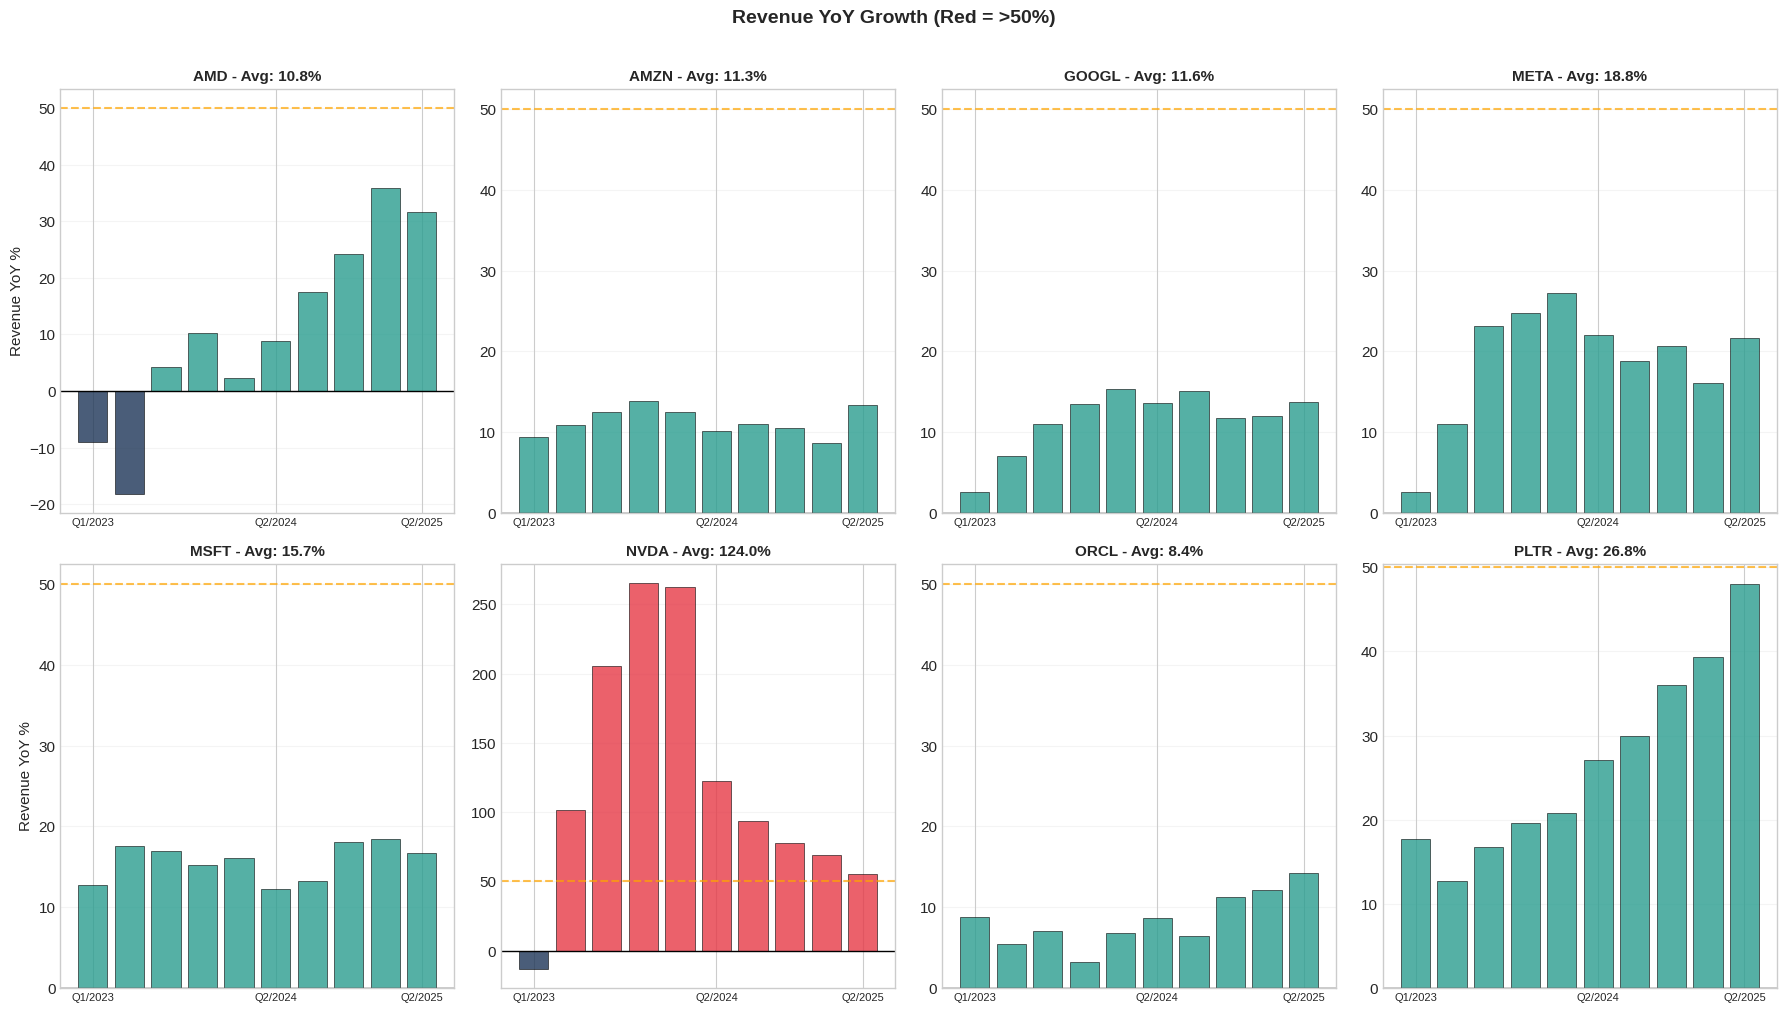

In [73]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, stock in enumerate(sorted(yoy_data['Stock'].unique())):
    ax = axes[idx]
    sdf = yoy_data[yoy_data['Stock'] == stock].dropna(subset=['Revenue_YoY']).sort_values('Date').reset_index(drop=True)
    if len(sdf) == 0: continue

    colors = ['#E63946' if v > 50 else '#2A9D8F' if v > 0 else '#1D3557' for v in sdf['Revenue_YoY']]
    ax.bar(range(len(sdf)), sdf['Revenue_YoY'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.axhline(y=0, color='black', linewidth=1)
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.7)

    x_labels = [s.split(' - ')[1] if ' - ' in s else s for s in sdf['Stock_Quarter_Year']]
    n = len(sdf)
    ax.set_xticks([0, n//2, n-1] if n > 2 else list(range(n)))
    ax.set_xticklabels([x_labels[i] for i in ([0, n//2, n-1] if n > 2 else list(range(n)))], fontsize=8)

    row = anomaly_df[anomaly_df['Stock'] == stock].iloc[0]
    risk_word = str(row['Risk']).split()[0] if pd.notna(row['Risk']) else ''
    ax.set_title(f"{stock} - Avg: {row['Avg_Rev_YoY']:.1f}%", fontsize=11, fontweight='bold')
    ax.set_ylabel('Revenue YoY %' if idx % 4 == 0 else '')
    ax.grid(True, alpha=0.2, axis='y')

fig.suptitle('Revenue YoY Growth (Red = >50%)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure4.png', dpi=300, bbox_inches='tight')


## Price YoY Growth

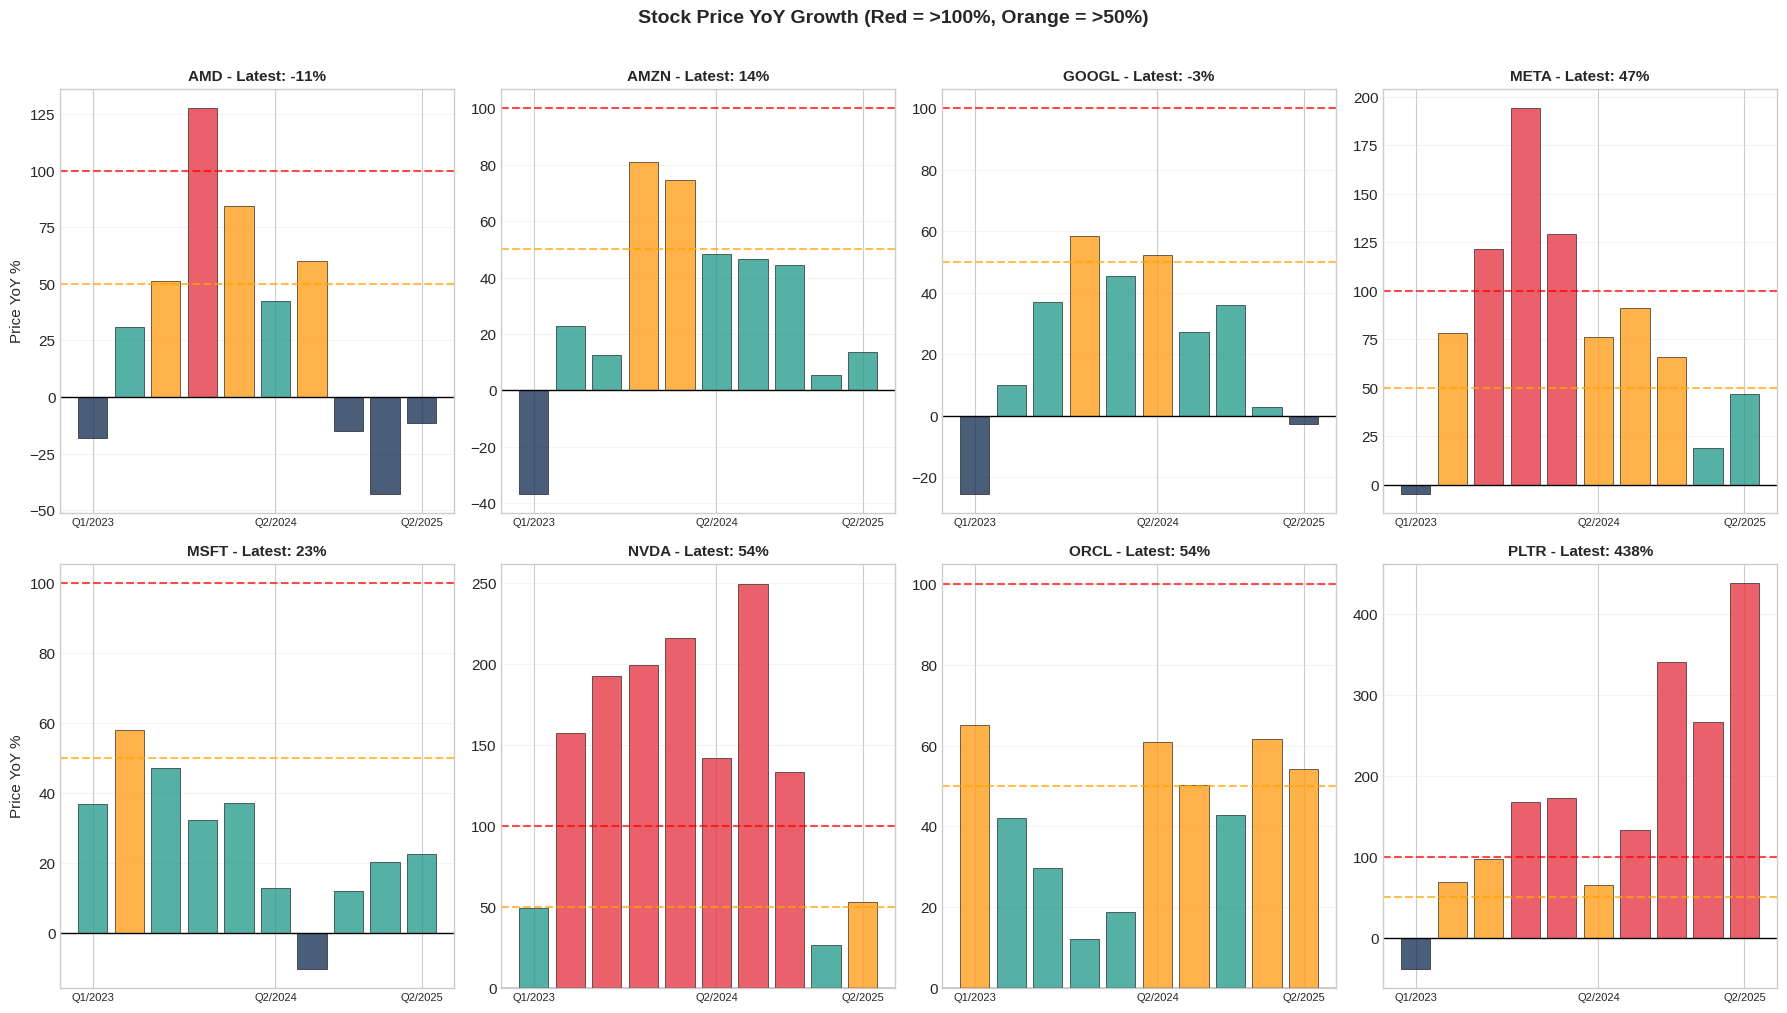

In [74]:
# Chart: Price YoY Growth
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, stock in enumerate(sorted(yoy_data['Stock'].unique())):
    ax = axes[idx]
    sdf = yoy_data[yoy_data['Stock'] == stock].dropna(subset=['Price_YoY']).sort_values('Date').reset_index(drop=True)
    if len(sdf) == 0: continue

    # Colors: Red if >100%, Orange if >50%, Green if positive, Blue if negative
    colors = ['#E63946' if v > 100 else '#FF9F1C' if v > 50 else '#2A9D8F' if v > 0 else '#1D3557' for v in sdf['Price_YoY']]

    ax.bar(range(len(sdf)), sdf['Price_YoY'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.axhline(y=0, color='black', linewidth=1)
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='50%')
    ax.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='100%')

    # X labels
    x_labels = [s.split(' - ')[1] if ' - ' in s else s for s in sdf['Stock_Quarter_Year']]
    n = len(sdf)
    tick_pos = [0, n//2, n-1] if n > 2 else list(range(n))
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([x_labels[i] for i in tick_pos], fontsize=8)

    # Title with latest value - Fixed: Removed emoji
    latest = sdf.iloc[-1]['Price_YoY']
    ax.set_title(f"{stock} - Latest: {latest:.0f}%", fontsize=11, fontweight='bold')
    ax.set_ylabel('Price YoY %' if idx % 4 == 0 else '')
    ax.grid(True, alpha=0.2, axis='y')

fig.suptitle('Stock Price YoY Growth (Red = >100%, Orange = >50%)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure5.png', dpi=300, bbox_inches='tight')
plt.show()


## Price YoY vs Revenue YoY Comparison (Side by Side)

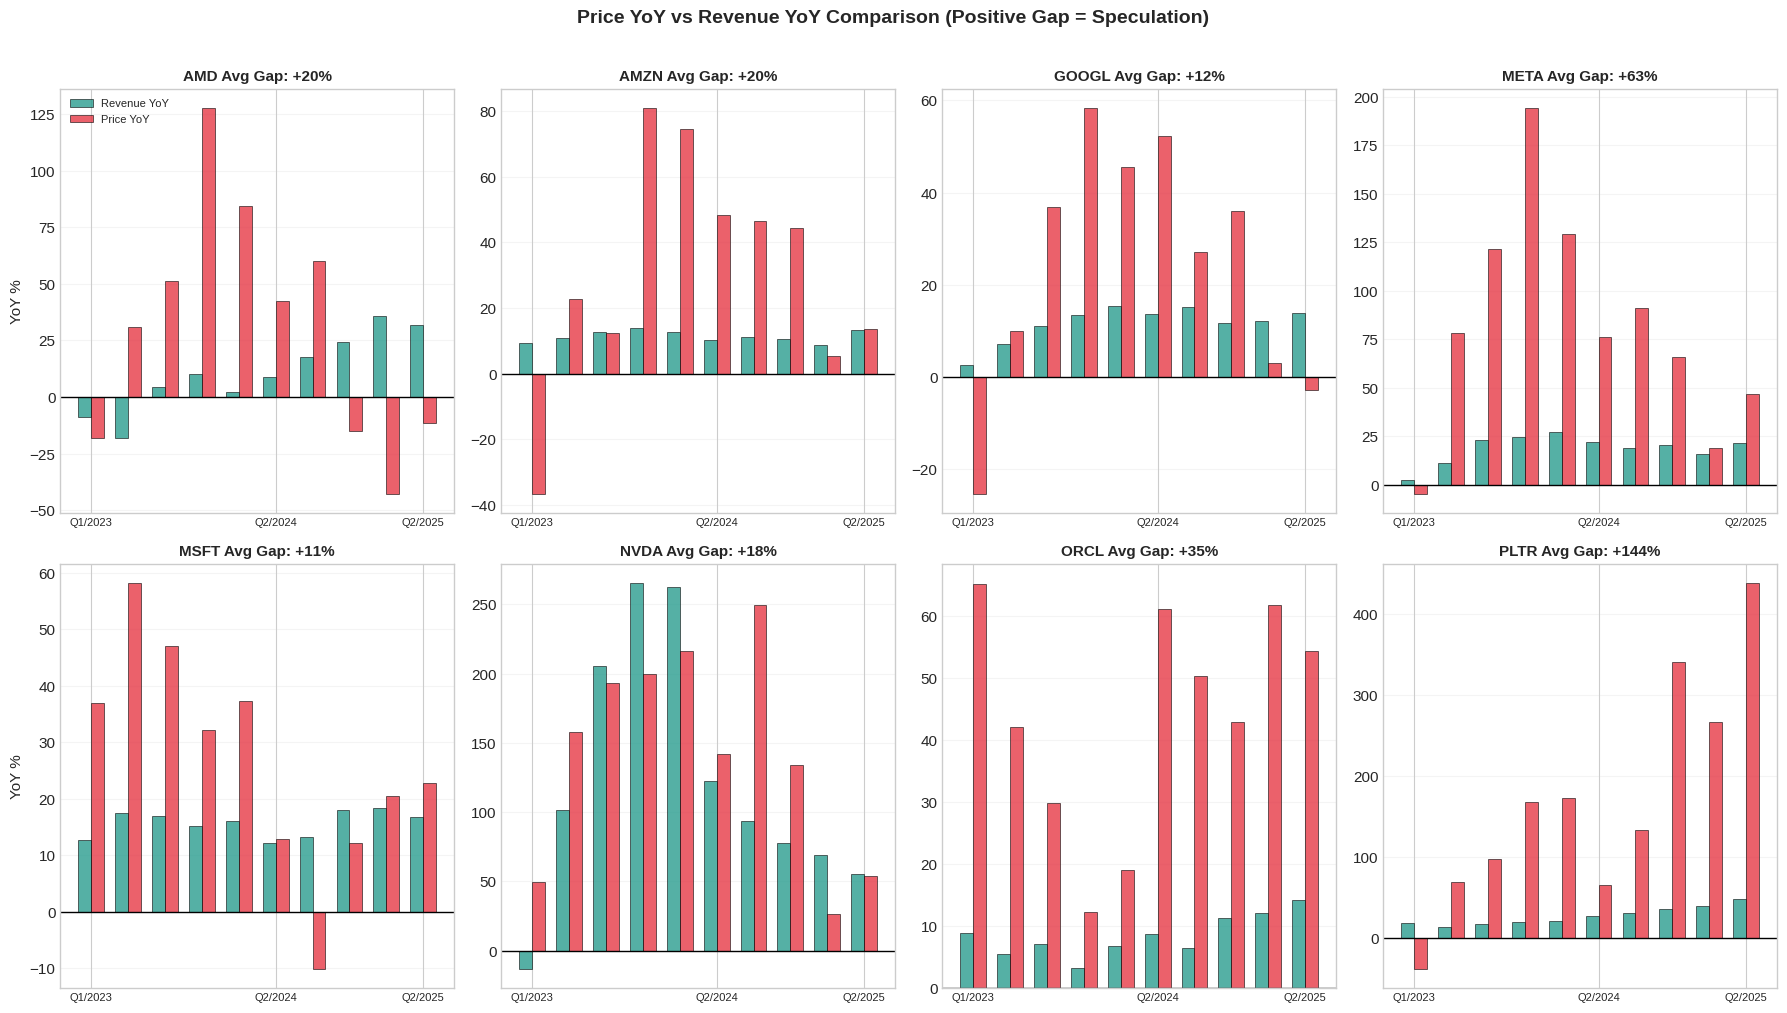

In [75]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, stock in enumerate(sorted(yoy_data['Stock'].unique())):
    ax = axes[idx]
    sdf = yoy_data[yoy_data['Stock'] == stock].dropna(subset=['Revenue_YoY', 'Price_YoY']).sort_values('Date').reset_index(drop=True)
    if len(sdf) == 0: continue

    x = np.arange(len(sdf))
    width = 0.35

    # Revenue bars
    bars1 = ax.bar(x - width/2, sdf['Revenue_YoY'], width, label='Revenue YoY', color='#2A9D8F', alpha=0.8, edgecolor='black', linewidth=0.5)
    # Price bars
    bars2 = ax.bar(x + width/2, sdf['Price_YoY'], width, label='Price YoY', color='#E63946', alpha=0.8, edgecolor='black', linewidth=0.5)

    ax.axhline(y=0, color='black', linewidth=1)

    # X labels
    x_labels = [s.split(' - ')[1] if ' - ' in s else s for s in sdf['Stock_Quarter_Year']]
    n = len(sdf)
    tick_pos = [0, n//2, n-1] if n > 2 else list(range(n))
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([x_labels[i] for i in tick_pos], fontsize=8)

    # Calculate average gap
    avg_gap = (sdf['Price_YoY'] - sdf['Revenue_YoY']).mean()
    ax.set_title(f"{stock} Avg Gap: {avg_gap:+.0f}%", fontsize=11, fontweight='bold')
    ax.set_ylabel('YoY %' if idx % 4 == 0 else '')
    ax.grid(True, alpha=0.2, axis='y')

# Legend
axes[0].legend(loc='upper left', fontsize=8)

fig.suptitle('Price YoY vs Revenue YoY Comparison (Positive Gap = Speculation)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure6.png', dpi=300, bbox_inches='tight')
plt.show()


## Summary Table: YoY Comparison

In [76]:
yoy_summary = yoy_data.groupby('Stock').agg({
    'Revenue_YoY': ['mean', 'max', 'min'],
    'Price_YoY': ['mean', 'max', 'min']
}).round(1)

yoy_summary.columns = ['Rev_Avg', 'Rev_Max', 'Rev_Min', 'Price_Avg', 'Price_Max', 'Price_Min']
yoy_summary['Gap_Avg'] = yoy_summary['Price_Avg'] - yoy_summary['Rev_Avg']
yoy_summary['Speculation'] = yoy_summary['Gap_Avg'].apply(lambda x: 'High' if x > 30 else ('Medium' if x > 10 else 'Low'))
yoy_summary = yoy_summary.sort_values('Gap_Avg', ascending=False)

print(" YoY Growth Summary:")
print("="*80)
yoy_summary

 YoY Growth Summary:


,Rev_Avg,Rev_Max,Rev_Min,Price_Avg,Price_Max,Price_Min,Gap_Avg,Speculation
Stock,,,,,,,,
PLTR,26.8,48.0,12.7,171.0,438.2,-38.5,144.2,High
META,18.8,27.3,2.6,81.7,194.1,-4.7,62.9,High
ORCL,8.4,14.2,3.3,43.8,65.1,12.2,35.4,High
AMD,10.8,35.9,-18.2,30.9,127.6,-42.8,20.1,Medium
AMZN,11.3,13.9,8.6,31.2,80.9,-36.6,19.9,Medium
NVDA,124.0,265.3,-13.2,142.2,249.6,26.6,18.2,Medium
GOOGL,11.6,15.4,2.6,24.1,58.3,-25.4,12.5,Medium
MSFT,15.7,18.4,12.3,27.0,58.2,-10.1,11.3,Medium


In [77]:
pip install adjustText

## Price vs Revenue YoY

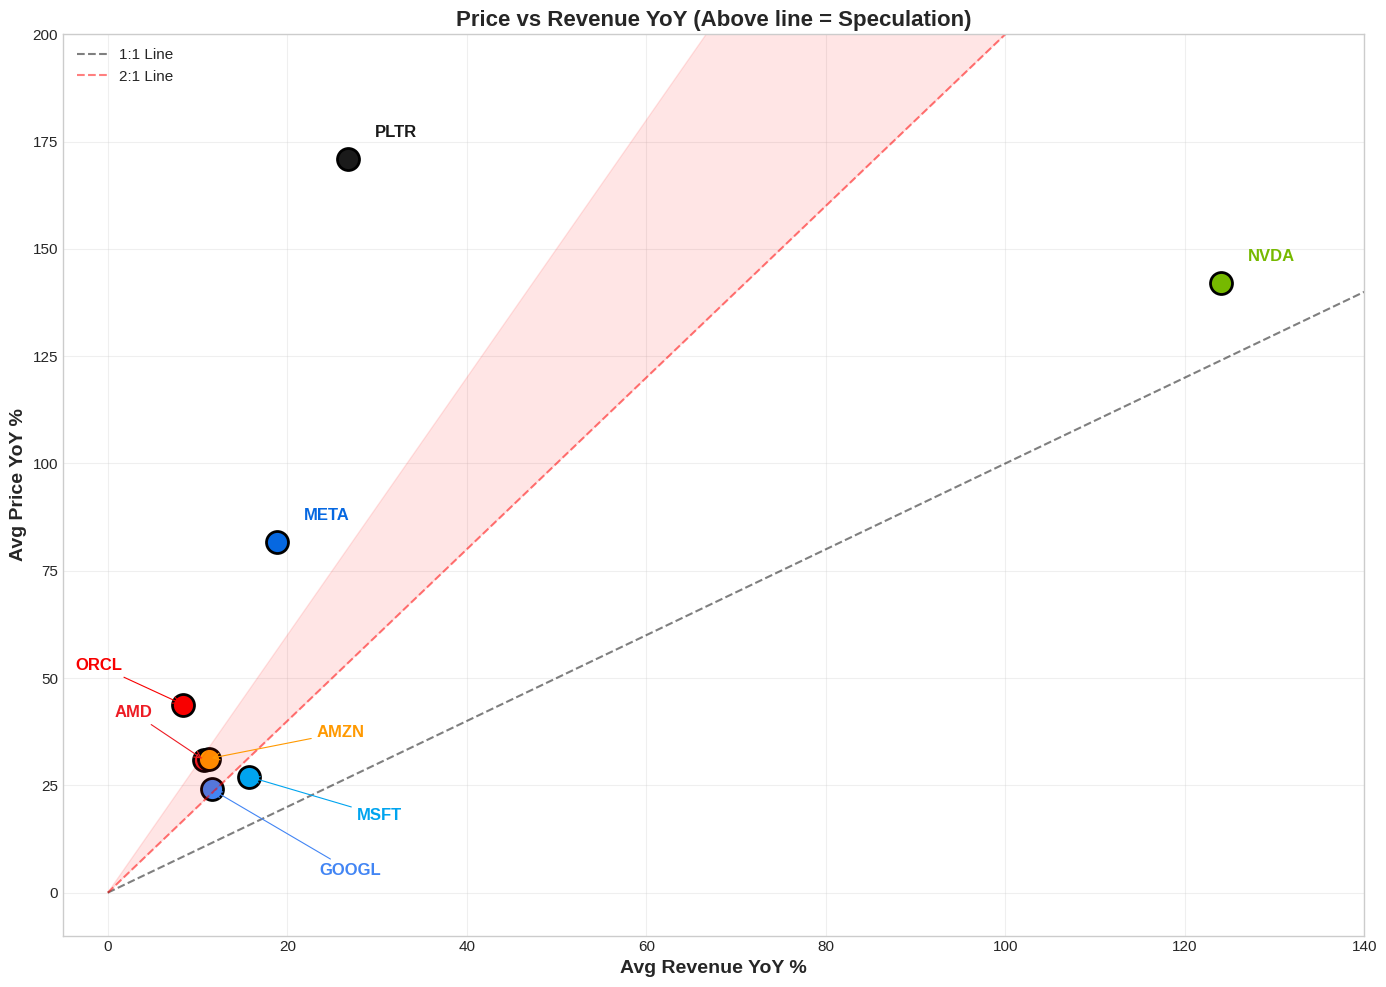

In [78]:

import matplotlib.pyplot as plt
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(14, 10))

summary = yoy_data.groupby('Stock').agg({'Revenue_YoY': 'mean', 'Price_YoY': 'mean'}).dropna()
colors = {'NVDA': '#76B900', 'AMD': '#ED1C24', 'AMZN': '#FF9900', 'GOOGL': '#4285F4',
          'META': '#0668E1', 'MSFT': '#00A4EF', 'ORCL': '#F80000', 'PLTR': '#1A1A1A'}

# Manual offsets for specific stocks (x_offset, y_offset) - Reduced distance for shorter arrows
manual_offsets = {
    'AMD': (-10, 10),
    'MSFT': (12, -10),
    'GOOGL': (12, -20),
    'AMZN': (12, 5),
    'NVDA': (3, 5),
    'ORCL': (-12, 8),
    'PLTR': (3, 5),
    'META': (3, 5),
}

# Stocks that need manual annotation WITH arrows
manual_stocks_with_arrow = ['AMD', 'MSFT', 'GOOGL', 'AMZN', 'ORCL']

# Stocks that need offset text WITHOUT arrows
manual_stocks_no_arrow = ['NVDA', 'PLTR', 'META']

# Collect texts for adjustText (excluding manual stocks)
texts = []

for stock in summary.index:
    x_val = summary.loc[stock, 'Revenue_YoY']
    y_val = summary.loc[stock, 'Price_YoY']

    ax.scatter(x_val, y_val, s=250, c=colors.get(stock, 'gray'), edgecolor='black', linewidth=2)

    stock_color = colors.get(stock, 'gray')

    if stock in manual_stocks_with_arrow:
        # Manual annotation with arrow
        offset = manual_offsets[stock]
        ax.annotate(stock,
                    xy=(x_val, y_val),
                    xytext=(x_val + offset[0], y_val + offset[1]),
                    fontsize=12, fontweight='bold', color=stock_color,
                    arrowprops=dict(arrowstyle='->', color=stock_color, lw=0.8))
    elif stock in manual_stocks_no_arrow:
        # Offset text without arrow
        offset = manual_offsets[stock]
        ax.text(x_val + offset[0], y_val + offset[1], stock, fontsize=12, fontweight='bold', color=stock_color)
    else:
        # Use adjustText for other stocks
        texts.append(ax.text(x_val, y_val, stock, fontsize=12, fontweight='bold', color=stock_color))

# Adjust text positions for non-manual stocks
adjust_text(texts,
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
            expand_points=(2, 2),
            force_points=(1, 1),
            force_text=(1, 1))

# Reference lines
ax.plot([0, 140], [0, 140], 'k--', alpha=0.5, label='1:1 Line')
ax.plot([0, 140], [0, 280], 'r--', alpha=0.5, label='2:1 Line')
ax.fill_between([0, 140], [0, 280], [0, 420], alpha=0.1, color='red')

# Set axis limits
ax.set_xlim(-5, 140)
ax.set_ylim(-10, 200)

ax.set_xlabel('Avg Revenue YoY %', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Price YoY %', fontsize=14, fontweight='bold')
ax.set_title('Price vs Revenue YoY (Above line = Speculation)', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure7.png', dpi=300, bbox_inches='tight')
plt.show()





##  Growth Report

In [79]:
print("="*30)
print("Growth Report")
print("="*30)

for _, r in anomaly_df.iterrows():
    print(f"\n {r['Stock']}")
    print(f"   Risk: {r['Risk']} | Score: {r['Score']:.0f}/100")
    print(f"   Avg Revenue YoY: {r['Avg_Rev_YoY']:.1f}% | Max: {r['Max_Rev_YoY']:.1f}%")
    print(f"   Price/Revenue Ratio: {r['Ratio']:.2f}x")
    print(f"   Flags: {r['Flags']}")

print("\n" + "="*30)
riskiest = anomaly_df.iloc[0]
safest = anomaly_df.iloc[-1]
print(f"\n HIGHEST RISK: {riskiest['Stock']} (Score: {riskiest['Score']:.0f})")
print(f" MOST SUSTAINABLE: {safest['Stock']} (Score: {safest['Score']:.0f})")

Growth Report

 NVDA
   Risk:  High | Score: 0/100
   Avg Revenue YoY: 124.0% | Max: 265.3%
   Price/Revenue Ratio: 1.15x
   Flags:  Revenue >100%

 PLTR
   Risk:  High | Score: 31/100
   Avg Revenue YoY: 26.8% | Max: 48.0%
   Price/Revenue Ratio: 6.38x
   Flags:  Speculation

 ORCL
   Risk: Medium | Score: 43/100
   Avg Revenue YoY: 8.4% | Max: 14.2%
   Price/Revenue Ratio: 5.20x
   Flags:  Speculation

 META
   Risk: Medium | Score: 52/100
   Avg Revenue YoY: 18.8% | Max: 27.3%
   Price/Revenue Ratio: 4.35x
   Flags:  Speculation

 AMD
   Risk: Medium | Score: 66/100
   Avg Revenue YoY: 10.8% | Max: 35.9%
   Price/Revenue Ratio: 2.87x
   Flags: High speculation

 AMZN
   Risk: Medium | Score: 67/100
   Avg Revenue YoY: 11.3% | Max: 13.9%
   Price/Revenue Ratio: 2.77x
   Flags: High speculation

 GOOGL
   Risk: Low | Score: 74/100
   Avg Revenue YoY: 11.6% | Max: 15.4%
   Price/Revenue Ratio: 2.08x
   Flags: High speculation

 MSFT
   Risk: Low | Score: 93/100
   Avg Revenue YoY: 15.7

##  Correlation Analysis

In [80]:
correlation_results = []

for stock in matched_data['Stock'].unique():
    stock_df = matched_data[matched_data['Stock'] == stock]
    if len(stock_df) >= 3:
        r, p = stats.pearsonr(stock_df['Revenue'], stock_df['Stock_Price'])
        correlation_results.append({'Stock': stock, 'Pearson_r': r, 'R_Squared': r**2})

corr_df = pd.DataFrame(correlation_results).sort_values('Pearson_r', ascending=False)
corr_df['Interpretation'] = corr_df['Pearson_r'].apply(
    lambda r: 'Strong' if r >= 0.8 else ('Moderate' if r >= 0.5 else 'Weak')
)
corr_df

,Stock,Pearson_r,R_Squared,Interpretation
5,NVDA,0.959691,0.921007,Strong
7,PLTR,0.947214,0.897215,Strong
4,MSFT,0.934859,0.873961,Strong
3,META,0.916462,0.839902,Strong
6,ORCL,0.834602,0.696561,Strong
2,GOOGL,0.827378,0.684554,Strong
1,AMZN,0.645012,0.416040,Moderate
0,AMD,0.188044,0.035361,Weak


## Correlation Bar Chart

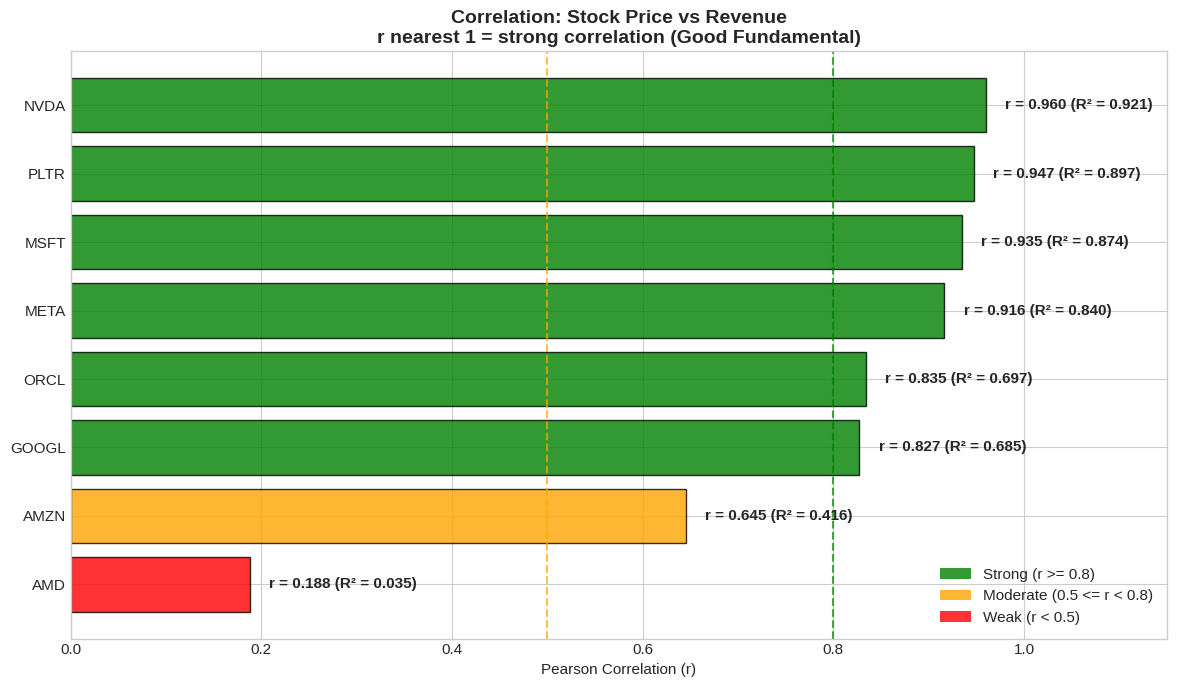

In [81]:
plt.figure(figsize=(12, 7))
corr_sorted = corr_df.sort_values('Pearson_r')
colors = corr_sorted['Pearson_r'].apply(lambda r: 'green' if r >= 0.8 else ('orange' if r >= 0.5 else 'red'))
bars = plt.barh(corr_sorted['Stock'], corr_sorted['Pearson_r'], color=colors.tolist(), alpha=0.8, edgecolor='black')
for bar, r, rsq in zip(bars, corr_sorted['Pearson_r'], corr_sorted['R_Squared']):
    plt.text(r + 0.02, bar.get_y() + bar.get_height()/2, f'r = {r:.3f} (R² = {rsq:.3f})', va='center', fontweight='bold')
plt.axvline(x=0.8, color='green', linestyle='--', alpha=0.7)
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7)
plt.xlim(0, 1.15)
plt.xlabel('Pearson Correlation (r)')
plt.title('Correlation: Stock Price vs Revenue\nr nearest 1 = strong correlation (Good Fundamental)', fontsize=14, fontweight='bold')
legend_elements = [
    Patch(facecolor='green', alpha=0.8, label='Strong (r >= 0.8)'),
    Patch(facecolor='orange', alpha=0.8, label='Moderate (0.5 <= r < 0.8)'),
    Patch(facecolor='red', alpha=0.8, label='Weak (r < 0.5)')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('figure8.png', dpi=300)
plt.show()

## Key Findings

In [82]:
# Key Findings Report

print("="*60)
print(" KEY FINDINGS - AI BUBBLE ANALYSIS")
print("="*60)

# Calculate Gap and sort by highest bubble
summary_report = summary.copy()
summary_report['Gap'] = summary_report['Price_YoY'] - summary_report['Revenue_YoY']
summary_report = summary_report.sort_values('Gap', ascending=False)

top_bubble = summary_report.reset_index().iloc[0]
print(f"\n Highest Bubble Signal: {top_bubble['Stock']}")
print(f"   - Price YoY: {top_bubble['Price_YoY']:.1f}%")
print(f"   - Revenue YoY: {top_bubble['Revenue_YoY']:.1f}%")
print(f"   - Gap: {top_bubble['Gap']:.1f}%")

# Check if corr_df exists
if 'corr_df' in dir():
    best_corr = corr_df.iloc[0]
    print(f"\n Best Correlation: {best_corr['Stock']}")
    print(f"   - Pearson r: {best_corr['Pearson_r']:.3f}")
    print(f"   - Interpretation: {best_corr['Interpretation']}")

print("\n" + "="*60)


 KEY FINDINGS - AI BUBBLE ANALYSIS

 Highest Bubble Signal: PLTR
   - Price YoY: 171.0%
   - Revenue YoY: 26.8%
   - Gap: 144.2%

 Best Correlation: NVDA
   - Pearson r: 0.960
   - Interpretation: Strong

